In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm

import torch
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# csv_url_p1="Head.csv"
# csv_url_p2="flow1.csv"
datap1 = pd.read_csv('P_quality_gt1.csv')
#datap2 = pd.read_csv('P_quality_lt1.csv')
datap_k1 = datap1.iloc[1:,1:]
datap_k1

,J511,J411,J414,J415,J416,J417,J418,J419,J310,J311,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
1,30.377136,65.563950,34.832300,86.600270,101.473120,30.047972,29.172054,25.540741,54.752983,50.656060,...,69.923460,69.923460,-0.000001,3.513322,2.818868,2.994066,5.463629,1.559531,0.728704,2.755558
2,30.984774,65.565380,34.979256,87.206210,102.138680,30.239360,29.384306,25.767653,56.856640,52.759140,...,74.713740,74.713740,-0.000001,4.048583,2.696090,3.968574,5.499999,2.215323,0.969480,3.352154
3,31.744596,65.848580,35.288322,89.095020,104.278595,30.543621,29.683752,26.048409,53.691456,49.587390,...,61.343662,61.343662,-0.000001,4.603395,2.617192,4.583615,5.452951,2.903393,1.202936,3.963001
4,31.385159,66.452090,36.976112,69.683266,92.083270,32.592120,31.910147,27.865423,52.882854,48.779580,...,60.581130,60.581130,-0.000001,5.187452,2.697759,3.722244,5.251726,3.750922,1.583545,4.233551
5,30.674273,68.020386,39.318940,68.957790,91.357790,35.201450,34.652145,30.163881,52.085570,47.982094,...,59.813553,59.813553,-0.000001,5.150339,2.973012,2.881570,5.020122,3.755406,2.408913,3.521921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,31.076563,66.204285,37.071110,85.146640,99.252240,32.859577,32.273132,28.675858,53.191235,49.115345,...,66.998140,66.998140,-0.000001,3.456163,3.544396,2.763187,5.417325,3.907387,3.558941,3.658201
5373,31.005732,66.483986,37.363777,84.982666,99.015830,33.163918,32.585110,29.001963,53.731045,49.652150,...,70.048040,70.048040,-0.000001,3.068503,3.486055,2.733114,5.499999,3.414673,3.914947,3.596000
5374,30.792479,66.142280,36.740090,84.099190,98.163050,32.461970,31.848015,28.451643,53.207336,49.144090,...,67.472150,67.472150,-0.000001,3.344523,3.434226,2.954664,5.499999,2.443932,3.955284,3.452316
5375,30.484478,66.131950,36.732925,84.470116,98.591170,32.449840,31.832180,28.432844,53.381737,49.307360,...,69.373924,69.373924,-0.000001,3.768330,3.328512,2.546372,5.499999,1.515654,3.933369,3.066655


In [3]:
dataq1 = pd.read_csv('Q_quality_gt1.csv')
#dataq2 = pd.read_csv('Q_quality_lt1.csv')
datap_k2 = dataq1.iloc[1:,1:]
datap_k2

,J511,J411,J414,J415,J416,J417,J418,J419,J310,J311,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
1,0.000133,0.001037,0.000849,0.000816,0.000808,0.000835,0.0,0.000809,0.003830,0.004501,...,0.004766,0.0,0.0040,0.000112,0.000000e+00,0.000339,0.000186,0.000986,0.000228,0.000000
2,0.000306,0.001689,0.001484,0.001445,0.001430,0.001472,0.0,0.001424,0.003547,0.004024,...,0.004772,0.0,0.0040,0.000266,0.000000e+00,0.000874,0.000204,0.001528,0.000480,0.000028
3,0.000429,0.002000,0.001673,0.001612,0.001593,0.001651,0.0,0.001591,0.003560,0.003618,...,0.000000,0.0,0.0040,0.000401,0.000000e+00,0.001111,0.000204,0.001751,0.000663,0.000066
4,0.000391,0.001955,0.001666,0.001581,0.001569,0.001644,0.0,0.001604,0.001789,0.000759,...,0.000000,0.0,0.0040,0.000518,7.069128e-07,0.001111,0.000204,0.001933,0.000866,0.000101
5,0.000079,0.001419,0.001242,0.001548,0.001536,0.001226,0.0,0.001201,0.000486,0.000499,...,0.000000,0.0,0.0008,0.000572,7.457869e-05,0.001111,0.000204,0.001962,0.001004,0.000101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,0.000630,0.002662,0.002326,0.002259,0.002240,0.002306,0.0,0.002249,0.002935,0.003279,...,0.003981,0.0,0.0056,0.003442,1.462248e-03,0.001199,0.002035,0.001725,0.002117,0.000464
5373,0.000613,0.002646,0.002288,0.002388,0.002364,0.002258,0.0,0.002196,0.003446,0.003858,...,0.004767,0.0,0.0056,0.003442,1.462248e-03,0.001196,0.002043,0.001736,0.002117,0.000464
5374,0.000603,0.002647,0.002303,0.002388,0.002365,0.002281,0.0,0.002135,0.003560,0.003977,...,0.004775,0.0,0.0056,0.003321,1.462248e-03,0.001235,0.002043,0.001736,0.002116,0.000464
5375,0.000360,0.002659,0.002327,0.002389,0.002368,0.002307,0.0,0.001839,0.003545,0.003932,...,0.004778,0.0,0.0056,0.003204,1.462248e-03,0.001235,0.002043,0.001736,0.002116,0.000464


In [4]:
datad1 = pd.read_csv('patt_quality_gt1.csv')
#dataq2 = pd.read_csv('Q_quality_lt1.csv')
datap_k5 = datad1.iloc[:,1:].T
datap_k5.columns 

RangeIndex(start=0, stop=334, step=1)

In [5]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

scaler_k1 = StandardScaler()
# transform data
datap_k11 = scaler_k1.fit_transform(datap_k1)
datap_k11=pd.DataFrame(datap_k11)
#datap_k11.columns = datap_k1.columns
datap_k11

,0,1,2,3,4,5,6,7,8,9,...,386,387,388,389,390,391,392,393,394,395
0,-1.015110,-0.308205,-1.034258,0.493092,0.612365,-1.164468,-0.629473,-0.945180,0.425856,0.420312,...,0.375855,0.375855,-2.117582e-22,-1.038725,0.077584,-0.583075,0.456893,-1.663874,-1.766141,-1.620429
1,0.050371,-0.307586,-0.992441,0.572643,0.750516,-1.116292,-0.551619,-0.843581,1.555456,1.550536,...,1.307076,1.307076,-2.117582e-22,-0.221440,-0.024227,0.735367,0.684658,-0.748356,-1.601018,-0.452446
2,1.382703,-0.185018,-0.904495,0.820614,1.194702,-1.039704,-0.441782,-0.717873,-0.144152,-0.154006,...,-1.292041,-1.292041,-2.117582e-22,0.625699,-0.089651,1.567477,0.390021,0.212223,-1.440916,0.743436
3,0.752438,0.076179,-0.424226,-1.727842,-1.336701,-0.524056,0.374859,0.095689,-0.578346,-0.588134,...,-1.440276,-1.440276,-2.117582e-22,1.517491,-0.022843,0.402101,-0.870145,1.395416,-1.179896,1.273105
4,-0.494086,0.754932,0.242437,-1.823086,-1.487290,0.132765,1.380623,1.124816,-1.006463,-1.016714,...,-1.589491,-1.589491,-2.117582e-22,1.460822,0.205404,-0.735274,-2.320557,1.401675,-0.613862,-0.120087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,0.211321,-0.031070,-0.397194,0.302254,0.151373,-0.456731,0.508002,0.458559,-0.412755,-0.407689,...,-0.192822,-0.192822,-2.117582e-22,-1.126001,0.679209,-0.895439,0.166915,1.613849,0.174821,0.146715
5372,0.087120,0.089983,-0.313914,0.280727,0.102301,-0.380123,0.622435,0.604571,-0.122894,-0.119203,...,0.400073,0.400073,-2.117582e-22,-1.717915,0.630831,-0.936125,0.684658,0.925995,0.418968,0.024941
5373,-0.286814,-0.057906,-0.491387,0.164740,-0.074711,-0.556817,0.352069,0.358167,-0.404109,-0.392241,...,-0.100675,-0.100675,-2.117582e-22,-1.296462,0.587853,-0.636384,0.684658,-0.429206,0.446631,-0.256356
5374,-0.826888,-0.062377,-0.493426,0.213437,0.014154,-0.559870,0.346260,0.349750,-0.310461,-0.304498,...,0.269026,0.269026,-2.117582e-22,-0.649355,0.500192,-1.188774,0.684658,-1.725128,0.431602,-1.011380


In [6]:
scaler_k2 = StandardScaler()
# transform data
datap_k22 = scaler_k2.fit_transform(datap_k2)
datap_k22=pd.DataFrame(datap_k22)
#datap_k22.columns = datap_k2.columns
datap_k22

,0,1,2,3,4,5,6,7,8,9,...,386,387,388,389,390,391,392,393,394,395
0,-1.908309,-3.817397,-3.323446,-1.838439,-1.842373,-3.246231,0.0,-3.729012,1.626241,1.763975,...,1.303445,0.0,-2.203411,-7.502075,-7.511058,-2.975250,-6.176904,-1.424244,-6.505836,-5.966572
1,-1.369819,-2.124087,-1.561592,-1.355385,-1.359589,-1.489023,0.0,-1.726416,1.383417,1.405103,...,1.306990,0.0,-2.203411,-7.173061,-7.511058,-1.332751,-6.114903,-0.089002,-5.541225,-5.687207
2,-0.988213,-1.316581,-1.037806,-1.227261,-1.232742,-0.993305,0.0,-1.185278,1.394066,1.099376,...,-1.287226,0.0,-2.203411,-6.883021,-7.511058,-0.604425,-6.114903,0.459873,-4.839284,-5.296444
3,-1.107850,-1.433228,-1.057255,-1.250733,-1.251350,-1.012364,0.0,-1.140498,-0.124202,-1.050988,...,-1.287226,0.0,-2.203411,-6.632841,-7.507200,-0.604425,-6.114903,0.909407,-4.065340,-4.938766
4,-2.076217,-2.826664,-2.231298,-1.276367,-1.277064,-2.167103,0.0,-2.454803,-1.240585,-1.245947,...,-1.287226,0.0,-6.984175,-6.517439,-7.104033,-0.604425,-6.114903,0.979811,-3.537821,-4.938766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,-0.365857,0.401604,0.774828,-0.729960,-0.730857,0.814116,0.0,0.956589,0.858642,0.844617,...,0.876768,0.0,0.186971,-0.382187,0.469383,-0.335230,0.096109,0.396671,0.722007,-1.269532
5372,-0.418290,0.360599,0.668099,-0.631501,-0.634186,0.682798,0.0,0.785703,1.297068,1.280432,...,1.303825,0.0,0.186971,-0.382187,0.469383,-0.343550,0.123126,0.423589,0.721148,-1.269532
5373,-0.449388,0.362488,0.711826,-0.631430,-0.633435,0.745497,0.0,0.585597,1.394644,1.369469,...,1.308225,0.0,0.186971,-0.641551,0.469383,-0.223071,0.123126,0.423589,0.718745,-1.269532
5374,-1.204382,0.394100,0.776633,-0.630646,-0.631236,0.816296,0.0,-0.375379,1.381547,1.336196,...,1.310245,0.0,0.186971,-0.890796,0.469383,-0.223071,0.123126,0.423589,0.718745,-1.269532


In [7]:
# from sklearn.preprocessing import MinMaxScaler

# scaler_f = MinMaxScaler()
# # transform data
# dataf = scaler_f.fit_transform(datap2.iloc[1:,1:])
# dataf=pd.DataFrame(dataf)
# dataf

In [8]:
sensor_no = [22, 26, 28,31, 38, 55, 58, 65, 70, 75, 79, 92, 102, 109, 114, 119, 128, 147, 148, 153, 164, 190, 195, 205, 206, 210, 211, 244, 252, 286, 303, 306, 313, 317, 327, 332, 339, 359, 372, 389, 390, 392, 393, 394, 395]

In [9]:
# flow_sensor = [429,430,
# 431
# ,432
# ,433
# ,434
# ,435
# ,436
# ,437
# ,438
# ,439
# ,70
# ,97
# ,296
# ,188
# ,28
# ,67
# ,269
# ,168]

In [10]:
#zero_flow = ['PU3','PU5','PU6','PU9','PU11','P446']

In [11]:
# datap_k22.drop(zero_flow, axis=1,inplace=True)
# datap_k22

In [12]:
datad1 = np.array(pd.read_csv('dossing_gt1.csv')).T
#datad2 = np.array(pd.read_csv('dossing_lt1.csv')).T
datap_k3 = pd.DataFrame(datad1[1:,:])
datap_k3

,0,1,2,3,4,5,6
0,0.0,1.2,0.2,0.0,1.2,0.6,0.4
1,0.0,1.2,0.2,0.0,1.2,0.6,0.4
2,0.0,1.2,0.2,0.0,1.2,0.6,0.4
3,0.0,1.2,0.2,0.0,1.2,0.6,0.4
4,1.2,1.4,1.0,0.2,1.2,1.2,0.4
...,...,...,...,...,...,...,...
5371,1.2,1.0,0.4,1.2,1.2,0.4,0.2
5372,1.0,1.2,0.6,0.6,0.0,0.0,0.0
5373,1.0,1.2,0.6,0.6,0.0,0.0,0.0
5374,1.0,1.2,0.6,0.6,0.0,0.0,0.0


In [13]:
# scaler_k3 = MinMaxScaler()
# # transform data
# datap_k3 = scaler_k3.fit_transform(datap_k3)
# datap_k3=pd.DataFrame(datap_k3)
# datap_k3

In [14]:
datap_k221=datap_k22.filter(sensor_no, axis=1)
datap_k221

,22,26,28,31,38,55,58,65,70,75,...,332,339,359,372,389,390,392,393,394,395
0,-3.584875,-3.231802,-3.649259,-1.840489,1.264100,-0.750785,2.066217,-2.691145,-3.993931,-4.071323,...,-3.171184,-1.558034,-0.604329,-1.750419,-7.502075,-7.511058,-6.176904,-1.424244,-6.505836,-5.966572
1,-3.584875,-1.477778,-3.184083,-1.381886,1.347302,-0.797998,2.170095,-1.166003,-2.133126,-3.454154,...,-3.171184,-1.299094,-0.974406,-1.256725,-7.173061,-7.511058,-6.114903,-0.089002,-5.541225,-5.687207
2,-1.803146,-0.986605,-2.165936,-1.257570,1.089693,-0.798270,0.994517,-1.187675,-1.326165,-2.269958,...,-2.681117,-0.790228,-0.659738,-1.125176,-6.883021,-7.511058,-6.114903,0.459873,-4.839284,-5.296444
3,-0.655793,-1.005597,-1.802710,-1.217264,-0.258916,-0.803197,0.660105,-1.343837,-1.426548,-1.258289,...,-2.406644,-0.896847,-0.846270,-1.135776,-6.632841,-7.507200,-6.114903,0.909407,-4.065340,-4.938766
4,-0.540949,-2.156345,-1.525879,-1.243832,-1.170204,-0.806900,-0.094511,-2.441614,-2.824534,-2.032889,...,-2.274781,-1.793910,-1.138143,-1.118656,-6.517439,-7.104033,-6.114903,0.979811,-3.537821,-4.938766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,-0.973119,0.818223,0.403900,-0.744906,0.843583,-1.261969,1.521274,1.209785,0.459362,0.169780,...,0.370158,-0.173307,-1.189189,-0.619584,-0.382187,0.469383,0.096109,0.396671,0.722007,-1.269532
5372,0.727129,0.683450,0.410563,-0.648382,1.262252,-1.404661,-0.140592,-0.409303,0.425278,0.460530,...,1.716127,-0.709629,-1.392110,-0.518300,-0.382187,0.469383,0.123126,0.423589,0.721148,-1.269532
5373,0.061956,0.748871,0.071575,-0.647851,1.344511,-1.342516,-0.046818,0.977209,0.421266,0.362790,...,-0.117523,-0.178638,-1.275735,-0.518300,-0.641551,0.469383,0.123126,0.423589,0.718745,-1.269532
5374,-1.170900,0.820439,-0.097676,-0.645437,1.351518,-1.322476,-0.005844,1.383676,0.452256,-0.004651,...,-1.105477,-0.618830,-1.211296,-0.518300,-0.890796,0.469383,0.123126,0.423589,0.718745,-1.269532


In [15]:
datap_k221.to_csv('see.csv', sep=',', encoding='utf-8', header='true')

In [16]:
datap_k111=datap_k11.filter(sensor_no, axis=1)
datap_k111

,22,26,28,31,38,55,58,65,70,75,...,332,339,359,372,389,390,392,393,394,395
0,-0.086671,-1.181178,-0.301276,0.621807,0.427969,0.993048,0.387942,-0.111076,-0.350628,-0.745478,...,1.345655,0.192897,0.0,-0.763269,-1.038725,0.077584,0.456893,-1.663874,-1.766141,-1.620429
1,-0.116256,-1.132231,-0.286912,0.764812,1.540040,1.204412,0.911109,-0.078335,-0.347307,-0.661343,...,1.493630,0.875250,0.0,-0.680721,-0.221440,-0.024227,0.684658,-0.748356,-1.601018,-0.452446
2,-0.031460,-1.057281,0.147984,1.225279,-0.332939,1.987694,1.951783,0.134189,-0.225485,0.590584,...,1.656973,2.019198,0.0,-0.568775,0.625699,-0.089651,0.390021,0.212223,-1.440916,0.743436
3,0.152336,-0.537160,0.358452,-1.301297,-0.720467,0.057271,2.400952,0.529449,0.049416,0.681183,...,1.893654,1.432813,0.0,0.384681,1.517491,-0.022843,-0.870145,1.395416,-1.179896,1.273105
4,0.976418,0.118281,1.238126,-1.456444,-1.103751,-0.157109,0.361769,1.105116,0.729289,1.652221,...,-0.341084,0.728379,0.0,1.419912,1.460822,0.205404,-2.320557,1.401675,-0.613862,-0.120087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,0.278750,-0.464103,-0.125828,0.138202,-0.387621,-0.405554,1.196508,-0.278352,-0.054054,-0.745774,...,-1.024256,-0.581359,0.0,0.493398,-1.126001,0.679209,0.166915,1.613849,0.174821,0.146715
5372,0.447377,-0.388307,0.418502,0.086826,-0.040524,-0.580644,-1.471403,-0.370516,0.064770,0.806950,...,-1.579640,-0.844952,0.0,0.605951,-1.717915,0.630831,0.684658,0.925995,0.418968,0.024941
5373,0.334076,-0.564689,0.256481,-0.095201,-0.370604,-1.094614,-1.987271,-0.969744,-0.086368,0.712282,...,0.920794,-1.661175,0.0,0.216750,-1.296462,0.587853,0.684658,-0.429206,0.446631,-0.256356
5374,0.303763,-0.567926,0.257441,-0.002999,-0.219560,-0.617842,-2.393827,-0.792302,-0.090342,0.727579,...,1.109920,-1.214434,0.0,0.214429,-0.649355,0.500192,0.684658,-1.725128,0.431602,-1.011380


In [17]:
# datap_k11 = k1.copy(deep=True)
# datap_k22 = k2.copy(deep=True)
# datap_k11.drop([5376,10753], axis=0, inplace=True)
# datap_k22.drop([5376,10753], axis=0, inplace=True)
# K1 = datap_k11
# K2 = datap_k22
# K3 = datap_k3 
# # dataf = K1

In [18]:
#K_p = np.hstack((datap_k11,datap_k22))
#K_p = pd.DataFrame(K_p)
# K_p=pd.concat([datap_k11,datap_k22], axis=1)
# K_p

In [19]:
# datap_k4 = pd.read_csv('Q_quality_gt1.csv')
# datap_k4 = datap_k4.iloc[1:,1:]
# datap_k4

In [20]:
# scaler_datap_k4 = MinMaxScaler()
# # transform data
# datap_k44 = scaler_datap_k4.fit_transform(datap_k4)
# datap_k44=pd.DataFrame(datap_k44)
# datap_k44.columns = datap_k4.columns
# datap_k44

In [21]:
# datap_k44=datap_k44.filter(sensor, axis=1)
# datap_k44

In [22]:
K_p=np.hstack((datap_k111,datap_k221,datap_k3)) #datap_k111,datap_k221,datap_k3,datap_k5
K_p=pd.DataFrame(K_p)
K_p

,0,1,2,3,4,5,6,7,8,9,...,87,88,89,90,91,92,93,94,95,96
0,-0.086671,-1.181178,-0.301276,0.621807,0.427969,0.993048,0.387942,-0.111076,-0.350628,-0.745478,...,-1.424244,-6.505836,-5.966572,0.0,1.2,0.2,0.0,1.2,0.6,0.4
1,-0.116256,-1.132231,-0.286912,0.764812,1.540040,1.204412,0.911109,-0.078335,-0.347307,-0.661343,...,-0.089002,-5.541225,-5.687207,0.0,1.2,0.2,0.0,1.2,0.6,0.4
2,-0.031460,-1.057281,0.147984,1.225279,-0.332939,1.987694,1.951783,0.134189,-0.225485,0.590584,...,0.459873,-4.839284,-5.296444,0.0,1.2,0.2,0.0,1.2,0.6,0.4
3,0.152336,-0.537160,0.358452,-1.301297,-0.720467,0.057271,2.400952,0.529449,0.049416,0.681183,...,0.909407,-4.065340,-4.938766,0.0,1.2,0.2,0.0,1.2,0.6,0.4
4,0.976418,0.118281,1.238126,-1.456444,-1.103751,-0.157109,0.361769,1.105116,0.729289,1.652221,...,0.979811,-3.537821,-4.938766,1.2,1.4,1.0,0.2,1.2,1.2,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,0.278750,-0.464103,-0.125828,0.138202,-0.387621,-0.405554,1.196508,-0.278352,-0.054054,-0.745774,...,0.396671,0.722007,-1.269532,1.2,1.0,0.4,1.2,1.2,0.4,0.2
5372,0.447377,-0.388307,0.418502,0.086826,-0.040524,-0.580644,-1.471403,-0.370516,0.064770,0.806950,...,0.423589,0.721148,-1.269532,1.0,1.2,0.6,0.6,0.0,0.0,0.0
5373,0.334076,-0.564689,0.256481,-0.095201,-0.370604,-1.094614,-1.987271,-0.969744,-0.086368,0.712282,...,0.423589,0.718745,-1.269532,1.0,1.2,0.6,0.6,0.0,0.0,0.0
5374,0.303763,-0.567926,0.257441,-0.002999,-0.219560,-0.617842,-2.393827,-0.792302,-0.090342,0.727579,...,0.423589,0.718745,-1.269532,1.0,1.2,0.6,0.6,0.0,0.0,0.0


In [23]:
# K1 = np.array(K1)
# K1 = K1.reshape((K1.shape[0], K1.shape[1],1))
# np.shape(K1)

In [24]:
# K2 = np.array(K2)
# K2 = K2.reshape((K2.shape[0], K2.shape[1],1))
# np.shape(K2)

In [25]:
# K3 = np.array(K3)
# #K3 = K3.reshape((K3.shape[0], K3.shape[1],1))
# np.shape(K3)

In [26]:
# K5 = []
# for i in range(K3.shape[0]):
#     K4 = np.array([K3[i]]*396)
#     K5.append(K4)
# K5 = np.array(K5)    
# np.shape(K5)

In [27]:
# K_p = np.concatenate((K1,K2), axis=2)
# np.shape(K_p)

In [28]:
#csv_url_m1="Pattern_32.csv"
#csv_url_m2="Pattern_32_1.csv"
dataY = pd.read_csv('Q_quality_gt1.csv')
#dataY2 = pd.read_csv(csv_url_m2)
#dataY= pd.concat([dataY1.iloc[:,1:], dataY2.iloc[:,1:]], ignore_index=True, axis=1)
# datap_k222 = datap_k2.copy(deep=True)
# datap_k222.drop([5376,10753], axis=0, inplace=True)
# datap_k222.drop(sensor_no, axis=1, inplace=True)
dataY = dataY.iloc[1:,1:]
dataY

,J511,J411,J414,J415,J416,J417,J418,J419,J310,J311,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
1,0.000133,0.001037,0.000849,0.000816,0.000808,0.000835,0.0,0.000809,0.003830,0.004501,...,0.004766,0.0,0.0040,0.000112,0.000000e+00,0.000339,0.000186,0.000986,0.000228,0.000000
2,0.000306,0.001689,0.001484,0.001445,0.001430,0.001472,0.0,0.001424,0.003547,0.004024,...,0.004772,0.0,0.0040,0.000266,0.000000e+00,0.000874,0.000204,0.001528,0.000480,0.000028
3,0.000429,0.002000,0.001673,0.001612,0.001593,0.001651,0.0,0.001591,0.003560,0.003618,...,0.000000,0.0,0.0040,0.000401,0.000000e+00,0.001111,0.000204,0.001751,0.000663,0.000066
4,0.000391,0.001955,0.001666,0.001581,0.001569,0.001644,0.0,0.001604,0.001789,0.000759,...,0.000000,0.0,0.0040,0.000518,7.069128e-07,0.001111,0.000204,0.001933,0.000866,0.000101
5,0.000079,0.001419,0.001242,0.001548,0.001536,0.001226,0.0,0.001201,0.000486,0.000499,...,0.000000,0.0,0.0008,0.000572,7.457869e-05,0.001111,0.000204,0.001962,0.001004,0.000101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,0.000630,0.002662,0.002326,0.002259,0.002240,0.002306,0.0,0.002249,0.002935,0.003279,...,0.003981,0.0,0.0056,0.003442,1.462248e-03,0.001199,0.002035,0.001725,0.002117,0.000464
5373,0.000613,0.002646,0.002288,0.002388,0.002364,0.002258,0.0,0.002196,0.003446,0.003858,...,0.004767,0.0,0.0056,0.003442,1.462248e-03,0.001196,0.002043,0.001736,0.002117,0.000464
5374,0.000603,0.002647,0.002303,0.002388,0.002365,0.002281,0.0,0.002135,0.003560,0.003977,...,0.004775,0.0,0.0056,0.003321,1.462248e-03,0.001235,0.002043,0.001736,0.002116,0.000464
5375,0.000360,0.002659,0.002327,0.002389,0.002368,0.002307,0.0,0.001839,0.003545,0.003932,...,0.004778,0.0,0.0056,0.003204,1.462248e-03,0.001235,0.002043,0.001736,0.002116,0.000464


In [29]:
# scaler_dataY1 = StandardScaler()
# # transform data
# dataY1 = scaler_dataY1.fit_transform(dataY)
# dataY1=pd.DataFrame(dataY1)
# dataY1.columns = dataY.columns
# dataY1

In [30]:
node_list = ['T1','J336','J218','J375','J369','J1153','J83','J142','J408','J438','J332','J432','J194','J171','J421','J156','J320','T7','J349','J384','T6','T2','J287','J238','T3','J260','J176','J157','J441','J38','J35','J385','J87','J245','J56','J77','T5','J134','J488','J489','J128','J169','J278','T4'] #'J17'

In [31]:
len(node_list)

44

In [32]:
zero_demand=[ 'J418', 'J210', 'J394', 'J399', 'J401', 'J406','J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J309', 'J317', 'J323']

In [33]:
len(zero_demand)

16

In [34]:
dataY.drop(zero_demand, axis=1, inplace=True)
dataY.drop(node_list, axis=1, inplace=True)

dataY

,J511,J411,J414,J415,J416,J417,J419,J310,J311,J312,...,J291,J292,J299,J300,J301,J302,J304,J306,J307,R1
1,0.000133,0.001037,0.000849,0.000816,0.000808,0.000835,0.000809,0.003830,0.004501,0.003087,...,0.000818,0.000811,0.000811,0.000813,0.004800,0.004786,0.004800,0.004789,0.004766,0.0040
2,0.000306,0.001689,0.001484,0.001445,0.001430,0.001472,0.001424,0.003547,0.004024,0.003105,...,0.001448,0.001435,0.001435,0.001439,0.004800,0.004789,0.004800,0.004795,0.004772,0.0040
3,0.000429,0.002000,0.001673,0.001612,0.001593,0.001651,0.001591,0.003560,0.003618,0.001802,...,0.001615,0.001599,0.001599,0.001604,0.004800,0.004782,0.004800,0.004789,0.004768,0.0040
4,0.000391,0.001955,0.001666,0.001581,0.001569,0.001644,0.001604,0.001789,0.000759,0.000836,...,0.001581,0.001589,0.001589,0.001593,0.004800,0.004679,0.004800,0.004789,0.004665,0.0040
5,0.000079,0.001419,0.001242,0.001548,0.001536,0.001226,0.001201,0.000486,0.000499,0.000832,...,0.001548,0.003749,0.003787,0.003833,0.000798,0.004578,0.005513,0.005513,0.004564,0.0008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5372,0.000630,0.002662,0.002326,0.002259,0.002240,0.002306,0.002249,0.002935,0.003279,0.002192,...,0.002263,0.003540,0.003549,0.003561,0.004000,0.003992,0.004000,0.003996,0.003981,0.0056
5373,0.000613,0.002646,0.002288,0.002388,0.002364,0.002258,0.002196,0.003446,0.003858,0.002581,...,0.002391,0.003465,0.003474,0.003485,0.004800,0.004787,0.004724,0.004724,0.004767,0.0056
5374,0.000603,0.002647,0.002303,0.002388,0.002365,0.002281,0.002135,0.003560,0.003977,0.002792,...,0.002392,0.002374,0.002374,0.002379,0.004800,0.004790,0.004619,0.004619,0.004775,0.0056
5375,0.000360,0.002659,0.002327,0.002389,0.002368,0.002307,0.001839,0.003545,0.003932,0.001926,...,0.002393,0.002373,0.002373,0.002378,0.004800,0.004791,0.004516,0.004516,0.004778,0.0056


In [35]:
scaler_dataY1 = StandardScaler()
# transform data
dataY1 = scaler_dataY1.fit_transform(dataY)
dataY1=pd.DataFrame(dataY1)
dataY1.columns = dataY.columns
dataY1

,J511,J411,J414,J415,J416,J417,J419,J310,J311,J312,...,J291,J292,J299,J300,J301,J302,J304,J306,J307,R1
0,-1.908309,-3.817397,-3.323446,-1.838439,-1.842373,-3.246231,-3.729012,1.626241,1.763975,1.810478,...,-1.837443,-1.833070,-1.833759,-1.832588,1.258696,1.142417,1.200278,1.196805,1.140692,-2.203411
1,-1.369819,-2.124087,-1.561592,-1.355385,-1.359589,-1.489023,-1.726416,1.383417,1.405103,1.831806,...,-1.353992,-1.328304,-1.329811,-1.329044,1.258696,1.143952,1.200278,1.200298,1.144786,-2.203411
2,-0.988213,-1.316581,-1.037806,-1.227261,-1.232742,-0.993305,-1.185278,1.394066,1.099376,0.305926,...,-1.225842,-1.195317,-1.197039,-1.196137,1.258696,1.139573,1.200278,1.196962,1.141729,-2.203411
3,-1.107850,-1.433228,-1.057255,-1.250733,-1.251350,-1.012364,-1.140498,-0.124202,-1.050988,-0.826055,...,-1.251809,-1.203610,-1.205319,-1.204955,1.258696,1.075091,1.200278,1.196885,1.077183,-2.203411
4,-2.076217,-2.826664,-2.231298,-1.276367,-1.277064,-2.167103,-2.454803,-1.240585,-1.245947,-0.830046,...,-1.277398,0.543638,0.570189,0.597763,-1.204560,1.012010,1.655733,1.659802,1.014040,-6.984175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5371,-0.365857,0.401604,0.774828,-0.729960,-0.730857,0.814116,0.956589,0.858642,0.844617,0.762767,...,-0.729168,0.374911,0.377872,0.378263,0.766270,0.645974,0.689463,0.689724,0.647998,0.186971
5372,-0.418290,0.360599,0.668099,-0.631501,-0.634186,0.682798,0.785703,1.297068,1.280432,1.218038,...,-0.630734,0.314139,0.317045,0.317469,1.258696,1.142704,1.151896,1.155297,1.141129,0.186971
5373,-0.449388,0.362488,0.711826,-0.631430,-0.633435,0.745497,0.585597,1.394644,1.369469,1.465331,...,-0.630656,-0.568225,-0.570962,-0.572187,1.258696,1.144536,1.084708,1.088020,1.146211,0.186971
5374,-1.204382,0.394100,0.776633,-0.630646,-0.631236,0.816296,-0.375379,1.381547,1.336196,0.451002,...,-0.629881,-0.569372,-0.572108,-0.572875,1.258696,1.145491,1.018849,1.022074,1.148542,0.186971


In [36]:
dataY1.columns[51]

'J57'

In [37]:
dataY1.shape

(5376, 336)

In [38]:
import sklearn

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(K_p,dataY1, test_size=0.2,shuffle=True)

np.shape(X_test)

(1076, 97)

In [40]:
np.shape(Y_test)

(1076, 336)

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [42]:
# define the keras model
model = Sequential()
model.add(Dense(256, input_shape=(97,), activation='sigmoid'))
model.add(Dense(256, activation='sigmoid'))
model.add(Dense(256, activation='relu'))
model.add(Dense(336))

In [43]:
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='mse', optimizer=opt,metrics=[tf.keras.losses.MeanAbsoluteError()])
# fit the keras model on the dataset
model.fit(X_train, Y_train, epochs=100, batch_size=10)


Epoch 1/100
430/430 [==============================] - 2s 2ms/step - loss: 0.5164 - mean_absolute_error: 0.5215
Epoch 2/100
430/430 [==============================] - 1s 2ms/step - loss: 0.2625 - mean_absolute_error: 0.3520
Epoch 3/100
430/430 [==============================] - 1s 2ms/step - loss: 0.2220 - mean_absolute_error: 0.3159
Epoch 4/100
430/430 [==============================] - 1s 2ms/step - loss: 0.1994 - mean_absolute_error: 0.2956
Epoch 5/100
430/430 [==============================] - 1s 2ms/step - loss: 0.1858 - mean_absolute_error: 0.2828
Epoch 6/100
430/430 [==============================] - 1s 2ms/step - loss: 0.1752 - mean_absolute_error: 0.2719
Epoch 7/100
430/430 [==============================] - 1s 2ms/step - loss: 0.1663 - mean_absolute_error: 0.2641
Epoch 8/100
430/430 [==============================] - 1s 2ms/step - loss: 0.1589 - mean_absolute_error: 0.2564
Epoch 9/100
430/430 [==============================] - 1s 2ms/step - loss: 0.1533 - mean_absolute_error:

430/430 [==============================] - 1s 2ms/step - loss: 0.0674 - mean_absolute_error: 0.1592
Epoch 74/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0669 - mean_absolute_error: 0.1588
Epoch 75/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0664 - mean_absolute_error: 0.1581
Epoch 76/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0664 - mean_absolute_error: 0.1585
Epoch 77/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0663 - mean_absolute_error: 0.1583
Epoch 78/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0656 - mean_absolute_error: 0.1575
Epoch 79/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0651 - mean_absolute_error: 0.1569
Epoch 80/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0650 - mean_absolute_error: 0.1571
Epoch 81/100
430/430 [==============================] - 1s 2ms/step - loss: 0.0647 - mean_absolute_error: 0.1

In [44]:
# # evaluate the keras model
# _, accuracy = model.evaluate(X, y)
# print('Accuracy: %.2f' % (accuracy*100))

In [45]:
y_pred = model.predict(X_test)

34/34 [==============================] - 0s 1ms/step


In [46]:
from sklearn.metrics import r2_score
s = r2_score(Y_test, y_pred)
s

0.9035092996880798

In [47]:
np.shape(y_pred)

(1076, 336)

In [48]:
y_pred1 = scaler_dataY1.inverse_transform(y_pred)

In [49]:
Y_test1 = scaler_dataY1.inverse_transform(Y_test)

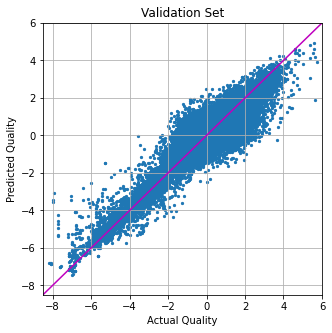

In [66]:
ax=plt.figure(1)
ax.set_figwidth(5)
ax.set_figheight(5)

plt.scatter(np.array(Y_test),y_pred,marker="o",s=5)
plt.axline([0,0], [1,1],color='m')
plt.grid()
plt.title('Validation Set')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')
plt.xlim(-8.5,6)
plt.ylim(-8.5,6)
# plt.xlim(0.0001)
# plt.ylim(-0.001,0.008)

# plt.savefig('Pred_Q.png', dpi=300,bbox_inches='tight')

In [51]:
np.shape(y_pred)

(1076, 336)

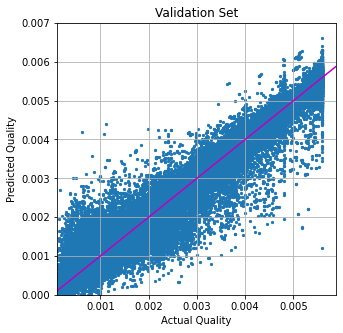

In [67]:
ax=plt.figure(1)
ax.set_figwidth(5)
ax.set_figheight(5)

plt.scatter(Y_test1,y_pred1,marker="o",s=5)
plt.axline([0,0], [0.0001,0.0001],color='m')
plt.grid()
plt.title('Validation Set')
plt.xlabel('Actual Quality')
plt.ylabel('Predicted Quality')

plt.xlim(0.0001)
plt.ylim(0,0.007)

# plt.savefig('Pred_Q1.png', dpi=300,bbox_inches='tight')

In [53]:
np.shape(y_pred)

(1076, 336)

In [54]:
dataY1.columns[76]

'J131'

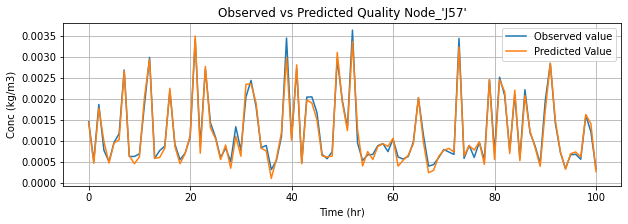

In [55]:
ax=plt.figure(1)
ax.set_figwidth(10)
ax.set_figheight(3)
plt.plot(Y_test1[200:301,51],label="Observed value")
plt.plot(y_pred1[200:301,51],label="Predicted Value")
#plt.plot(Mdf,color='k')
plt.title("Observed vs Predicted Quality Node_'J57'")
plt.xlabel("Time (hr)")
plt.ylabel("Conc (kg/m3)")
#plt.ylim(0,0.001)
plt.legend()
plt.grid()
#plt.savefig('Quality_1.png', dpi=300,bbox_inches='tight')
plt.show()

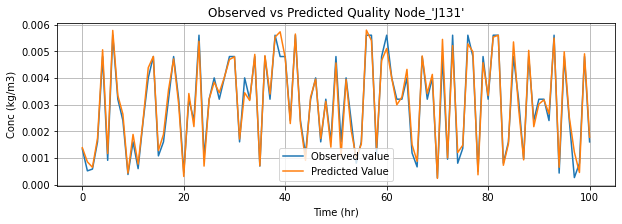

In [56]:
ax=plt.figure(1)
ax.set_figwidth(10)
ax.set_figheight(3)
plt.plot(Y_test1[200:301,76],label="Observed value")
plt.plot(y_pred1[200:301,76],label="Predicted Value")
#plt.plot(Mdf,color='k')
plt.title("Observed vs Predicted Quality Node_'J131'")
plt.xlabel("Time (hr)")
plt.ylabel("Conc (kg/m3)")
#plt.ylim(0,0.001)
plt.legend()
plt.grid()
#plt.savefig('Quality_2.png', dpi=300,bbox_inches='tight')
plt.show()

In [57]:
from sklearn.metrics import r2_score
R2 = [[],[]]
for i in range(336):
    s = r2_score(np.array(Y_test)[:,i], y_pred[:,i])
    print(f'Node {i} have R2 {s}')
    R2[0].append(i)
    R2[1].append(s)

Node 0 have R2 0.9018753693141137
Node 1 have R2 0.9654374059288267
Node 2 have R2 0.9792447635899201
Node 3 have R2 0.9668414758870455
Node 4 have R2 0.9727817314328682
Node 5 have R2 0.9786597917378782
Node 6 have R2 0.8947000229631537
Node 7 have R2 0.9818789757679957
Node 8 have R2 0.9818216635975084
Node 9 have R2 0.9633195541178805
Node 10 have R2 0.9285232114641904
Node 11 have R2 0.9751636909606628
Node 12 have R2 0.9646437365556795
Node 13 have R2 0.9705978931339008
Node 14 have R2 0.9824373534786629
Node 15 have R2 0.800212617602346
Node 16 have R2 0.9646349711047687
Node 17 have R2 0.9719261227820098
Node 18 have R2 0.9704458272139646
Node 19 have R2 0.9737900691539149
Node 20 have R2 0.97512065198006
Node 21 have R2 0.980703496686184
Node 22 have R2 0.9484873411547909
Node 23 have R2 0.9490525810150037
Node 24 have R2 0.8576320629411984
Node 25 have R2 0.8584875628040747
Node 26 have R2 0.9831057305380181
Node 27 have R2 0.9836878879345957
Node 28 have R2 0.9673191054374031

Node 310 have R2 0.33851830014421
Node 311 have R2 0.6908416668688803
Node 312 have R2 0.954815911655358
Node 313 have R2 0.9495610201584114
Node 314 have R2 0.9485514193759856
Node 315 have R2 0.975834644363298
Node 316 have R2 0.4396522161765378
Node 317 have R2 0.9853045841808219
Node 318 have R2 0.9851960652263614
Node 319 have R2 0.0
Node 320 have R2 0.0
Node 321 have R2 0.9834496799783826
Node 322 have R2 0.9851872188237678
Node 323 have R2 0.917122942458265
Node 324 have R2 0.9643401602538301
Node 325 have R2 0.9654333365046517
Node 326 have R2 0.9657545446110729
Node 327 have R2 0.9194158330057407
Node 328 have R2 0.9190182666616669
Node 329 have R2 0.9185223023246802
Node 330 have R2 0.9228114692067845
Node 331 have R2 0.9706500033989244
Node 332 have R2 0.8621581233015573
Node 333 have R2 0.8616729859216226
Node 334 have R2 0.9708828843419425
Node 335 have R2 0.9818994215541589


In [58]:
R_2 = pd.DataFrame(R2)

In [59]:
R_2

,0,1,2,3,4,5,6,7,8,9,...,326,327,328,329,330,331,332,333,334,335
0,0.000000,1.000000,2.000000,3.000000,4.000000,5.00000,6.0000,7.000000,8.000000,9.00000,...,326.000000,327.000000,328.000000,329.000000,330.000000,331.00000,332.000000,333.000000,334.000000,335.000000
1,0.901875,0.965437,0.979245,0.966841,0.972782,0.97866,0.8947,0.981879,0.981822,0.96332,...,0.965755,0.919416,0.919018,0.918522,0.922811,0.97065,0.862158,0.861673,0.970883,0.981899
